# Notebook 01 — Extracción de PDFs IDEXX

**Fase 1 · Módulo 1A** — Extracción batch de hemogramas caninos desde PDFs generados por IDEXX ProCyte One vía VetConnect PLUS.

**Entrada:** `Sin Limpieza/batch_*.pdf` (298 archivos, ~10 pacientes/PDF)  
**Salida:** `data/interim/idexx_extracted.csv`

| Sección | Contenido |
|---|---|
| **1** | Setup y dependencias |
| **2** | Exploración de estructura PDF |
| **3** | Diseño de patrones de extracción (regex por formato VetConnect) |
| **4** | Función de extracción por página |
| **5** | Extracción batch (298 archivos) |
| **6–6b** | Construcción del DataFrame y filtrado a registros caninos |
| **7** | Reporte de extracción: volumen temporal y distribución de razas |
| **8** | Exportación a CSV |
| **9** | Resumen de artefactos generados |


### Guia rapida del codigo

- Lee PDFs IDEXX desde la carpeta configurada al inicio.
- Extrae encabezados, valores CBC y comentarios con `pdfplumber` y patrones regex.
- Genera `data/interim/idexx_extracted.csv` y figuras de control en `outputs/`.
- Las funciones clave son `extract_header`, `extract_cbc_values`, `extract_comments` y `extract_pdf`.


## 1. Setup

In [1]:
import pdfplumber
import pandas as pd
import numpy as np
import re
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from tqdm import tqdm
from IPython.display import display, Image
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

PROJECT_ROOT = Path.cwd().parents[1]
PDF_DIR = PROJECT_ROOT / "Sin Limpieza"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
OUTPUTS = PROJECT_ROOT / "outputs"
INTERIM_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS.mkdir(parents=True, exist_ok=True)

def save_and_show(fig, filename, outputs_dir=OUTPUTS):
    """Guarda la figura, cierra el objeto y muestra inline."""
    path = outputs_dir / filename
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    display(Image(filename=str(path)))
    print(f"Guardado: {path}")

pdf_files = sorted(PDF_DIR.glob("batch_*.pdf"))
print(f"Directorio PDFs: {PDF_DIR}")
print(f"PDFs encontrados: {len(pdf_files)}")


Directorio PDFs: /home/edwinb/tesis/hemogramas-proyectoICC/Sin Limpieza
PDFs encontrados: 298


## 2. Exploracion de estructura PDF

In [2]:
# Abrir un PDF de ejemplo para entender la estructura
sample_pdf = pdf_files[0]
pdf = pdfplumber.open(sample_pdf)

print(f"Archivo: {sample_pdf.name}")
print(f"Paginas: {len(pdf.pages)}")
print(f"Estructura: ~10 pacientes por PDF, 2 paginas c/u")
print(f"  Pagina impar: tabla de resultados CBC")
print(f"  Pagina par: scatter plots + comentarios IDEXX")
print()
print("--- TEXTO PAGINA 1 ---")
print(pdf.pages[0].extract_text()[:1200])
pdf.close()

Archivo: batch_1.pdf
Paginas: 20
Estructura: ~10 pacientes por PDF, 2 paginas c/u
  Pagina impar: tabla de resultados CBC
  Pagina par: scatter plots + comentarios IDEXX

--- TEXTO PAGINA 1 ---
1 888 433-9987
TOBY CAPELLA
PET OWNER: FANNY CAPELLA VET BOCA SERVICIOS VETERINARIOS LAB ID:
SPECIES: Canine INDEPENDENCIA #25. ORDER ID:
BREED: Canine, Other santo domingo, do 0000 DATE OF RECEIPT: 12/3/25
GENDER: Male DATE OF RESULT: 12/3/25
AGE: ACCOUNT #:
PATIENT ID: ATTENDING VET: Dr. Emmanuel Gómez
IDEXX Services: ProCyte One Hematology Analyzer
Hematology
12/3/25 11:04 AM
TEST RESULT REFERENCE VALUE
RBC 7.69 5.65 - 8.87 M/µL
Hematocrit 57.2 37.3 - 61.7 %
Hemoglobin 18.2 13.1 - 20.5 g/dL
MCV 74.3 61.6 - 73.5 fL H
MCH 23.7 21.2 - 25.9 pg
MCHC 31.9 32.0 - 37.9 g/dL L
RDW 18.7 13.6 - 21.7 %
% Reticulocytes 0.8 %
Reticulocytes 64.2 10.0 - 110.0 K/µL
WBC *11.08 5.05 - 16.76 K/µL
% Neutrophils *72.0 %
% Lymphocytes *14.3 %
% Monocytes *10.2 %
% Eosinophils *3.5 %
% Basophils *0.0 %
Neutrophils 7

In [3]:
# Examinar pagina de comentarios (pagina 2)
pdf = pdfplumber.open(sample_pdf)
text_p2 = pdf.pages[1].extract_text()
print("--- TEXTO PAGINA 2 (scatter plots + comentarios) ---")
print(text_p2[:800] if text_p2 else "Sin texto")
pdf.close()

--- TEXTO PAGINA 2 (scatter plots + comentarios) ---
1 888 433-9987
TOBY CAPELLA PET OWNER: FANNY CAPELLA DATE OF RESULT: 12/3/25 LAB ID:
RBC Run
PLT
RETICS
WBC
RBC
RBC_FRAG
Download
WBC Run
MONO
EOS
NEU
BASO
URBC
LYM
Download
* Confirmar con la gráfica de puntos y / o un frotis sanguíneo.
Monocitosis - considere la inflamación (en caso de linfopenia, considere la
respuesta glucocorticoide).
®
Generated by VetConnect PLUS February 19, 2026 08:43 PM © 2025 IDEXX Laboratories, Inc. All rights reserved. US D1072841 S. Page 2 of 2


## 3. Diseno de patrones de extraccion

Cada pagina de resultados tiene un formato consistente generado por VetConnect PLUS.
Los campos se extraen con regex sobre el texto plano de cada pagina.

In [4]:
# Patrones regex para extraer campos del header del paciente
HEADER_PATTERNS = {
    'patient_name': r'^(.+?)\nPET OWNER:',
    'pet_owner':    r'PET OWNER:\s*(.+?)\s*(?:VET|LAB)',
    'clinic':       r'VET\s+(.+?)\s*LAB ID',
    'species':      r'SPECIES:\s*(\w+)',
    'breed':        r'BREED:\s*(.+?)\s*(?:santo|ORDER|$)',
    'gender':       r'GENDER:\s*(\w+)',
    'age':          r'AGE:\s*(\d[^\n]+?)\s*(?:ACCOUNT|\n|$)',
    'date_receipt': r'DATE\s*OF RECEIPT:\s*(\d+/\d+/\d+)',
    'date_result':  r'DATE OF RESULT:\s*(\d+/\d+/\d+)',
    'attending_vet': r'ATTENDING VET:\s*(.+?)$',
}

# Patrones para valores CBC — formato: "TEST valor ref_low - ref_high UNIT [FLAG]"
CBC_FIELDS = [
    'RBC', 'Hematocrit', 'Hemoglobin', 'MCV', 'MCHC', 'MCH', 'RDW',
    '% Reticulocytes', 'Reticulocytes',
    'WBC',
    '% Neutrophils', '% Lymphocytes', '% Monocytes', '% Eosinophils', '% Basophils',
    'Neutrophils', 'Lymphocytes', 'Monocytes', 'Eosinophils', 'Basophils',
    'Platelets', 'PDW', 'MPV', 'Plateletcrit',
]

# Regex para cada linea CBC
CBC_LINE_RE = re.compile(
    r'(?P<test>(?:% )?\w+)\s+'
    r'(?P<result>[*]?[\d.]+)\s+'
    r'(?:(?P<ref_low>[\d.]+)\s*-\s*(?P<ref_high>[\d.]+))?\s*'
    r'(?P<unit>[A-Za-z/%µ]+)?\s*'
    r'(?P<flag>[HL])?\s*$',
    re.MULTILINE
)

print(f"Header patterns: {len(HEADER_PATTERNS)}")
print(f"CBC fields: {len(CBC_FIELDS)}")

Header patterns: 10
CBC fields: 24


## 4. Funcion de extraccion por pagina

In [5]:
def extract_header(text: str) -> dict:
    """Extrae metadata del paciente del header de la pagina."""
    header = {}
    for field, pattern in HEADER_PATTERNS.items():
        match = re.search(pattern, text, re.MULTILINE | re.IGNORECASE)
        header[field] = match.group(1).strip() if match else None
    return header


def extract_cbc_values(text: str) -> dict:
    """Extrae valores CBC de la pagina de resultados."""
    values = {}
    flags = {}
    
    for line in text.split('\n'):
        line = line.strip()
        if not line:
            continue
        
        for field in CBC_FIELDS:
            # Buscar linea que empiece con el nombre del campo
            if line.startswith(field):
                # Extraer el valor numerico despues del nombre
                remainder = line[len(field):].strip()
                # El valor puede tener * prefix
                match = re.match(r'[*]?([\d.]+)', remainder)
                if match:
                    try:
                        val = float(match.group(1))
                        # Normalizar nombre del campo
                        clean_name = field.replace('% ', 'pct_').replace(' ', '_')
                        values[clean_name] = val
                        
                        # Buscar flag H o L al final de la linea
                        if line.rstrip().endswith(' H'):
                            flags[clean_name] = 'H'
                        elif line.rstrip().endswith(' L'):
                            flags[clean_name] = 'L'
                    except ValueError:
                        pass
                break
    
    return values, flags


def extract_comments(text: str) -> str:
    """Extrae comentarios IDEXX de la pagina de scatter plots."""
    if not text:
        return None
    
    # Comentarios IDEXX aparecen despues del SEGUNDO 'Download'
    # (el primero cierra el scatter RBC Run, el segundo el WBC Run)
    # Tambien pueden empezar con "* Confirmar..." o ser texto libre
    lines = text.split('\n')
    comment_lines = []
    download_count = 0
    
    for line in lines:
        line = line.strip()
        if line == 'Download':
            download_count += 1
            continue
        if 'Generated by' in line or 'IDEXX Laboratories' in line:
            break
        if download_count >= 2 and line:
            comment_lines.append(line)
    
    comment = ' '.join(comment_lines).strip().rstrip('®').strip()
    return comment if comment else None


print("Funciones de extraccion definidas.")

Funciones de extraccion definidas.


In [6]:
# Test con una pagina
pdf = pdfplumber.open(sample_pdf)
text_p1 = pdf.pages[0].extract_text()
text_p2 = pdf.pages[1].extract_text()

header = extract_header(text_p1)
values, flags = extract_cbc_values(text_p1)
comments = extract_comments(text_p2)

print("Header:")
for k, v in header.items():
    print(f"  {k}: {v}")
print(f"\nCBC values ({len(values)} campos):")
for k, v in values.items():
    flag = f" [{flags[k]}]" if k in flags else ""
    print(f"  {k}: {v}{flag}")
print(f"\nComentarios: {comments[:200] if comments else 'Ninguno'}")
pdf.close()

Header:
  patient_name: TOBY CAPELLA
  pet_owner: FANNY CAPELLA
  clinic: BOCA SERVICIOS VETERINARIOS
  species: Canine
  breed: Canine, Other
  gender: Male
  age: None
  date_receipt: 12/3/25
  date_result: 12/3/25
  attending_vet: Dr. Emmanuel Gómez

CBC values (24 campos):
  RBC: 7.69
  Hematocrit: 57.2
  Hemoglobin: 18.2
  MCV: 74.3 [H]
  MCH: 23.7
  MCHC: 31.9 [L]
  RDW: 18.7
  pct_Reticulocytes: 0.8
  Reticulocytes: 64.2
  WBC: 11.08
  pct_Neutrophils: 72.0
  pct_Lymphocytes: 14.3
  pct_Monocytes: 10.2
  pct_Eosinophils: 3.5
  pct_Basophils: 0.0
  Neutrophils: 7.98
  Lymphocytes: 1.58
  Monocytes: 1.13 [H]
  Eosinophils: 0.39
  Basophils: 0.0
  Platelets: 450.0
  PDW: 14.4
  MPV: 11.8
  Plateletcrit: 0.53 [H]

Comentarios: * Confirmar con la gráfica de puntos y / o un frotis sanguíneo. Monocitosis - considere la inflamación (en caso de linfopenia, considere la respuesta glucocorticoide).


## 5. Extraccion batch

In [7]:
def extract_pdf(pdf_path: Path) -> list[dict]:
    """Extrae todos los pacientes de un PDF IDEXX."""
    records = []
    errors = []
    
    try:
        pdf = pdfplumber.open(pdf_path)
    except Exception as e:
        return [], [{'file': pdf_path.name, 'error': str(e)}]
    
    n_pages = len(pdf.pages)
    
    # Iterar de 2 en 2: pagina resultados + pagina scatter
    for i in range(0, n_pages, 2):
        try:
            # Pagina de resultados
            text_results = pdf.pages[i].extract_text()
            if not text_results or 'Hematology' not in text_results:
                continue
            
            header = extract_header(text_results)
            values, flags = extract_cbc_values(text_results)
            
            if not values:  # Sin datos CBC, skip
                continue
            
            # Pagina de scatter plots / comentarios
            comments = None
            if i + 1 < n_pages:
                text_scatter = pdf.pages[i + 1].extract_text()
                comments = extract_comments(text_scatter)
            
            # Construir registro
            record = {
                'pdf_filename': pdf_path.name,
                'page_number': i + 1,
                'source_dataset': 'IDEXX',
                **header,
                **values,
                'idexx_comments': comments,
                'has_scatter_plots': True,
                'extraction_timestamp': datetime.now().isoformat(),
            }
            
            # Agregar flags como columnas separadas
            for field, flag in flags.items():
                record[f'{field}_flag'] = flag
            
            records.append(record)
            
        except Exception as e:
            errors.append({
                'file': pdf_path.name,
                'page': i + 1,
                'error': str(e)
            })
    
    pdf.close()
    return records, errors


print("Funcion extract_pdf definida.")

Funcion extract_pdf definida.


In [8]:
# Extraccion batch de todos los PDFs
all_records = []
all_errors = []

for pdf_path in tqdm(pdf_files, desc="Extrayendo PDFs"):
    records, errors = extract_pdf(pdf_path)
    all_records.extend(records)
    all_errors.extend(errors)

print(f"\nExtraccion completada:")
print(f"  Registros extraidos: {len(all_records):,}")
print(f"  Errores: {len(all_errors)}")
print(f"  PDFs procesados: {len(pdf_files)}")

if all_errors:
    print(f"\nPrimeros errores:")
    for err in all_errors[:10]:
        print(f"  {err}")

Extrayendo PDFs:   0%|          | 0/298 [00:00<?, ?it/s]

Extrayendo PDFs: 100%|██████████| 298/298 [18:43<00:00,  3.77s/it]


Extraccion completada:
  Registros extraidos: 2,770
  Errores: 0
  PDFs procesados: 298


## 6. Construccion del DataFrame

In [9]:
df_idexx = pd.DataFrame(all_records)

print(f"Shape: {df_idexx.shape}")
print(f"\nColumnas ({len(df_idexx.columns)}):")
for i, col in enumerate(df_idexx.columns, 1):
    non_null = df_idexx[col].notna().sum()
    print(f"  {i:2d}. {col}: {non_null}/{len(df_idexx)} no-nulos")

Shape: (2770, 58)

Columnas (58):
   1. pdf_filename: 2770/2770 no-nulos
   2. page_number: 2770/2770 no-nulos
   3. source_dataset: 2770/2770 no-nulos
   4. patient_name: 2770/2770 no-nulos
   5. pet_owner: 2770/2770 no-nulos
   6. clinic: 2770/2770 no-nulos
   7. species: 2770/2770 no-nulos
   8. breed: 2770/2770 no-nulos
   9. gender: 2770/2770 no-nulos
  10. age: 1961/2770 no-nulos
  11. date_receipt: 2770/2770 no-nulos
  12. date_result: 2770/2770 no-nulos
  13. attending_vet: 2770/2770 no-nulos
  14. RBC: 2764/2770 no-nulos
  15. Hematocrit: 2766/2770 no-nulos
  16. Hemoglobin: 2756/2770 no-nulos
  17. MCV: 2769/2770 no-nulos
  18. MCH: 2757/2770 no-nulos
  19. MCHC: 2746/2770 no-nulos
  20. RDW: 2703/2770 no-nulos
  21. pct_Reticulocytes: 2747/2770 no-nulos
  22. Reticulocytes: 2748/2770 no-nulos
  23. WBC: 2740/2770 no-nulos
  24. pct_Neutrophils: 2740/2770 no-nulos
  25. pct_Lymphocytes: 2740/2770 no-nulos
  26. pct_Monocytes: 2740/2770 no-nulos
  27. pct_Eosinophils: 2740/277

## 6b. Filtrado: solo registros caninos

In [10]:
# Filtrar registros: solo caninos (tesis canina)
n_before = len(df_idexx)
species_counts = df_idexx['species'].value_counts()
print("Distribucion de species antes del filtro:")
print(species_counts.to_string())

df_idexx = df_idexx[df_idexx['species'].str.contains('Canine', case=False, na=False)].reset_index(drop=True)

# Limpiar ruido en gender (valores like DATE, ACCOUNT son artefactos del regex)
valid_genders = ['Male', 'Female', 'Unknown', 'Intact Male', 'Intact Female',
                  'Neutered Male', 'Spayed Female']
df_idexx['gender'] = df_idexx['gender'].apply(
    lambda g: g if (pd.notna(g) and any(v.lower() in g.lower() for v in valid_genders)) else None
)

n_after = len(df_idexx)
print(f"\nRegistros antes del filtro: {n_before}")
print(f"Registros despues del filtro (solo Canine): {n_after}")
print(f"Registros eliminados (felinos u otros): {n_before - n_after}")


Distribucion de species antes del filtro:
species
Canine    2480
Feline     289
Equine       1

Registros antes del filtro: 2770
Registros despues del filtro (solo Canine): 2480
Registros eliminados (felinos u otros): 290


In [11]:
# Estadisticas de campos CBC
cbc_cols = [c for c in df_idexx.columns if c in [
    'RBC', 'Hematocrit', 'Hemoglobin', 'MCV', 'MCHC', 'MCH', 'RDW',
    'pct_Reticulocytes', 'Reticulocytes', 'WBC',
    'pct_Neutrophils', 'pct_Lymphocytes', 'pct_Monocytes', 'pct_Eosinophils', 'pct_Basophils',
    'Neutrophils', 'Lymphocytes', 'Monocytes', 'Eosinophils', 'Basophils',
    'Platelets', 'PDW', 'MPV', 'Plateletcrit'
]]

if cbc_cols:
    print(f"Campos CBC encontrados: {len(cbc_cols)}\n")
    print(df_idexx[cbc_cols].describe().round(2).to_string())

Campos CBC encontrados: 24

           RBC  Hematocrit  Hemoglobin      MCV      MCH     MCHC      RDW  pct_Reticulocytes  Reticulocytes      WBC  pct_Neutrophils  pct_Lymphocytes  pct_Monocytes  pct_Eosinophils  pct_Basophils  Neutrophils  Lymphocytes  Monocytes  Eosinophils  Basophils  Platelets      PDW      MPV  Plateletcrit
count  2475.00     2477.00     2470.00  2480.00  2471.00  2461.00  2423.00            2479.00        2480.00  2452.00          2452.00          2452.00        2452.00          2452.00        2452.00      2452.00      2452.00    2452.00      2452.00    2452.00    2480.00  2480.00  2417.00       2417.00
mean      6.57       47.08       16.48    71.67    25.30    35.30    17.51               1.53          72.57    15.12            68.04            18.70           9.48             3.65           0.13        10.77         2.44       1.42         0.48       0.02     332.93    14.60    11.59          0.39
std       1.74       12.99        4.30     5.46     3.55     5.

## 7. Reporte de extraccion

Registros por PDF:
  Media: 8.3
  Min: 1
  Max: 10


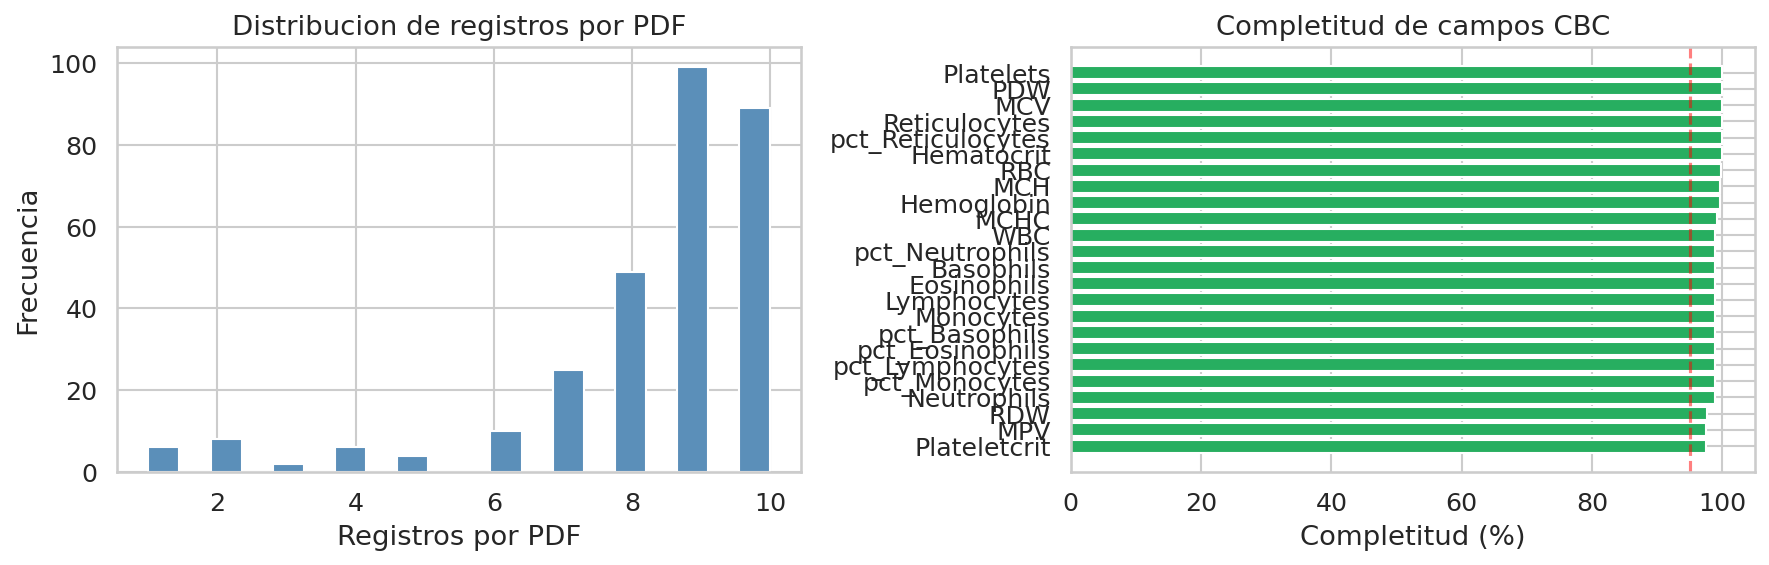

Guardado: /home/edwinb/tesis/hemogramas-proyectoICC/outputs/nb01_registros_por_pdf.png


In [12]:
# Calcular tasa de extraccion
records_per_pdf = df_idexx.groupby("pdf_filename").size()

print(f"Registros por PDF:")
print(f"  Media: {records_per_pdf.mean():.1f}")
print(f"  Min: {records_per_pdf.min()}")
print(f"  Max: {records_per_pdf.max()}")

# Distribucion
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(records_per_pdf, bins=20, color="#5B8FB9", edgecolor="white")
axes[0].set_xlabel("Registros por PDF")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribucion de registros por PDF")

# Completitud de campos CBC
if cbc_cols:
    completeness = df_idexx[cbc_cols].notna().mean().sort_values() * 100
    axes[1].barh(completeness.index, completeness.values, color="#27AE60")
    axes[1].set_xlabel("Completitud (%)")
    axes[1].set_title("Completitud de campos CBC")
    axes[1].axvline(95, color="red", linestyle="--", alpha=0.5)

plt.tight_layout()
save_and_show(fig, "nb01_registros_por_pdf.png")


In [13]:
# Distribucion de razas y genero
print("Razas mas frecuentes:")
if 'breed' in df_idexx.columns:
    print(df_idexx['breed'].value_counts().head(15).to_string())

print(f"\nGenero:")
if 'gender' in df_idexx.columns:
    print(df_idexx['gender'].value_counts().to_string())

print(f"\nFechas:")
if 'date_result' in df_idexx.columns:
    print(df_idexx['date_result'].value_counts().head(10).to_string())

Razas mas frecuentes:
breed
Canine, Mixed Breed    398
Chihuahua              239
Canine, Other          172
Mixed                  126
Yorkshire Terrier      124
Bulldog                119
Siberian Husky         103
German Shepherd        100
Shih Tzu               100
Other                  100
Golden Retriever        96
French Bulldog          96
Pomeranian              75
Pug                     64
Poodle                  59

Genero:
gender
Female    1262
Male      1137

Fechas:
date_result
11/25/25    10
6/4/24      10
6/20/25     10
11/7/25     10
1/22/25      9
2/28/25      9
7/15/24      9
11/12/25     9
6/17/25      9
12/3/25      8


### 7.1 Volumen temporal de registros extraidos

Cantidad de registros extraidos por mes. Permite verificar que la cobertura
temporal es razonablemente uniforme y detectar meses con extraccion anomala.

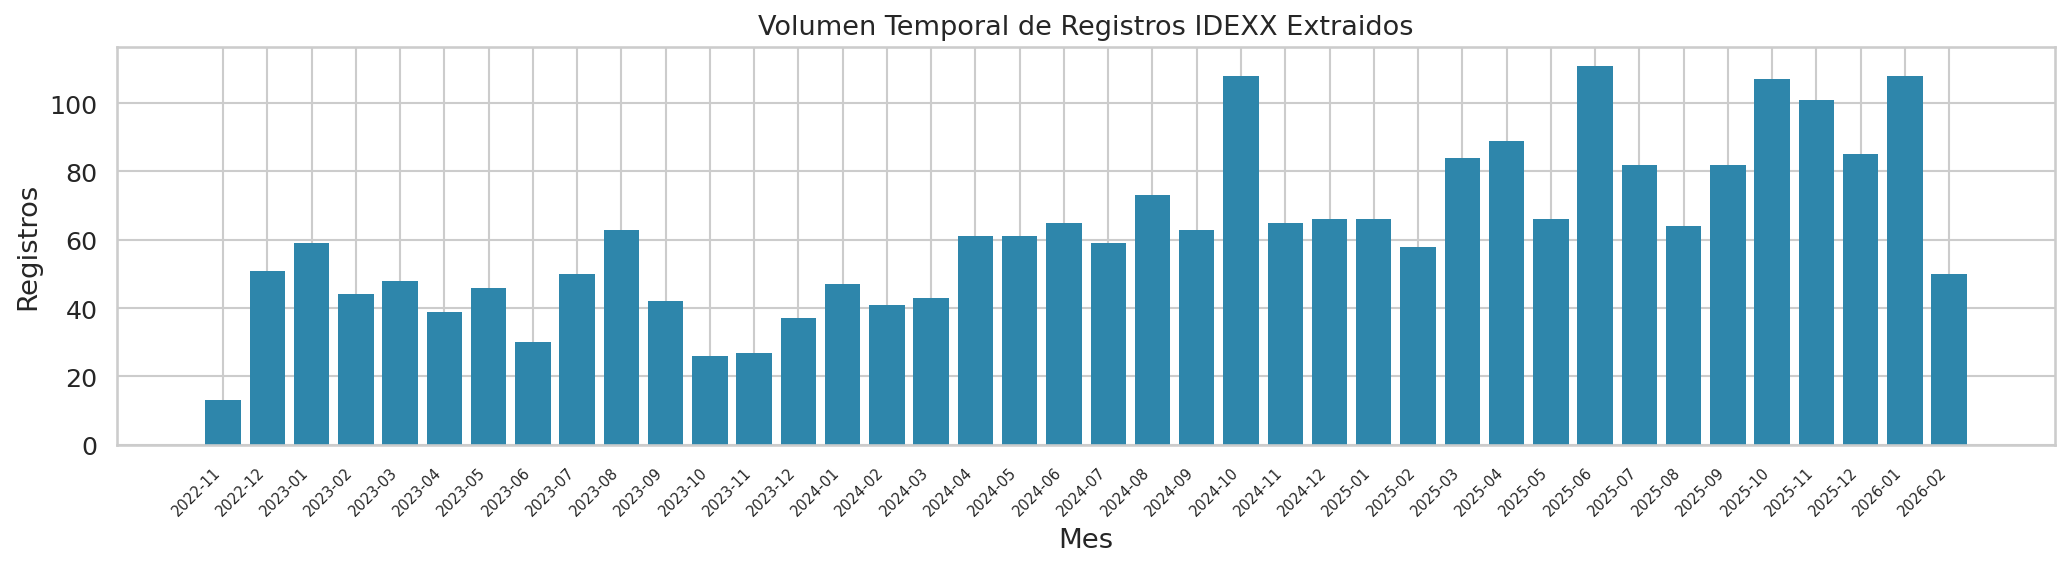

Guardado: /home/edwinb/tesis/hemogramas-proyectoICC/outputs/nb01_volumen_temporal.png


In [14]:
# Volumen temporal por mes
if "date_result" in df_idexx.columns:
    dates = pd.to_datetime(df_idexx["date_result"], errors="coerce")
    valid_dates = dates.dropna()
    monthly = valid_dates.dt.to_period("M").value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(range(len(monthly)), monthly.values, color="#2E86AB", edgecolor="none")
    ax.set_xticks(range(len(monthly)))
    ax.set_xticklabels([str(p) for p in monthly.index], rotation=45, ha="right", fontsize=7)
    ax.set_xlabel("Mes")
    ax.set_ylabel("Registros")
    ax.set_title("Volumen Temporal de Registros IDEXX Extraidos", fontsize=13)
    plt.tight_layout()
    save_and_show(fig, "nb01_volumen_temporal.png")
else:
    print("Columna date_result no disponible para grafico temporal.")


### 7.2 Distribucion de razas (top 20)

Las razas mas frecuentes en el dataset. Util para entender sesgos
demograficos en la poblacion de muestras.

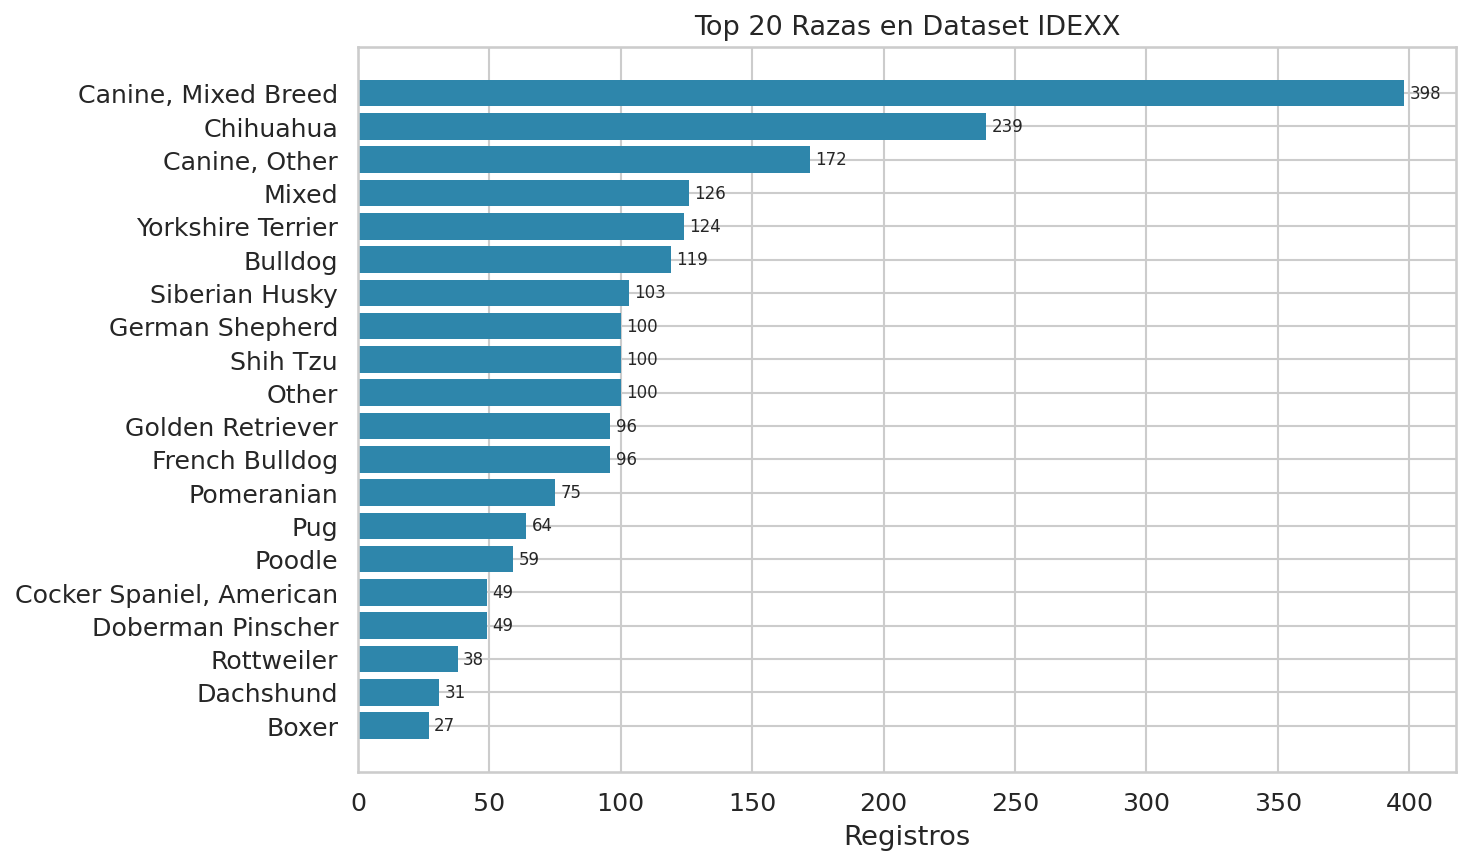

Guardado: /home/edwinb/tesis/hemogramas-proyectoICC/outputs/nb01_distribucion_razas.png


In [15]:
if "breed" in df_idexx.columns:
    breed_counts = df_idexx["breed"].value_counts().head(20)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(breed_counts.index[::-1], breed_counts.values[::-1],
            color="#2E86AB", edgecolor="none")
    ax.set_xlabel("Registros")
    ax.set_title("Top 20 Razas en Dataset IDEXX", fontsize=13)
    for i, (name, val) in enumerate(zip(breed_counts.index[::-1], breed_counts.values[::-1])):
        ax.text(val + 2, i, str(val), va="center", fontsize=8)
    plt.tight_layout()
    save_and_show(fig, "nb01_distribucion_razas.png")
else:
    print("Columna breed no disponible.")


## 8. Export

In [16]:
# Visualizar antes de guardar
print(f"Shape: {df_idexx.shape}")
print(f"\nPrimeras filas:")
print(df_idexx.head())


Shape: (2480, 58)

Primeras filas:
  pdf_filename  page_number source_dataset        patient_name  \
0  batch_1.pdf            1          IDEXX        TOBY CAPELLA   
1  batch_1.pdf            3          IDEXX     SULTAN ALMANZAR   
2  batch_1.pdf            5          IDEXX          RYUU URENA   
3  batch_1.pdf            7          IDEXX          RYUU URENA   
4  batch_1.pdf            9          IDEXX  BLUE JOSE DIONICIO   

         pet_owner                       clinic species  \
0    FANNY CAPELLA  BOCA SERVICIOS VETERINARIOS  Canine   
1  MARTIN ALMANZAR  BOCA SERVICIOS VETERINARIOS  Canine   
2     ISAMAR URENA  BOCA SERVICIOS VETERINARIOS  Canine   
3     ISAMAR URENA  BOCA SERVICIOS VETERINARIOS  Canine   
4    JOSE DIONICIO  BOCA SERVICIOS VETERINARIOS  Canine   

                            breed gender      age  ... Platelets_flag  \
0                   Canine, Other   Male      NaN  ...            NaN   
1                 German Shepherd   Male  1 Years  ...            N

In [17]:
# Guardar dataset IDEXX extraido
output_path = INTERIM_DIR / 'idexx_extracted.csv'
df_idexx.to_csv(output_path, index=False)

file_size_kb = output_path.stat().st_size / 1024
print(f"Guardado: {output_path}")
print(f"  Registros: {len(df_idexx):,}")
print(f"  Columnas: {len(df_idexx.columns)}")
print(f"  Tamano: {file_size_kb:.1f} KB")

# Verificacion de criterio de aceptacion
total_expected = records_per_pdf.sum()
print(f"\nCriterio de aceptacion:")
print(f"  Tasa de extraccion: {len(df_idexx)}/{total_expected} = {len(df_idexx)/total_expected*100:.1f}%")

Guardado: /home/edwinb/tesis/hemogramas-proyectoICC/data/interim/idexx_extracted.csv
  Registros: 2,480
  Columnas: 58
  Tamano: 1104.8 KB

Criterio de aceptacion:
  Tasa de extraccion: 2480/2480 = 100.0%


## 9. Resumen

In [18]:
print("=" * 50)
print("  RESUMEN — Notebook 01: Extraccion IDEXX")
print("=" * 50)
print(f"  PDFs procesados:    {len(pdf_files)}")
print(f"  Registros extraidos: {len(all_records):,}")
print(f"  Errores:            {len(all_errors)}")
print(f"  Campos CBC:         {len(cbc_cols)}")
print(f"  Output: {output_path}")
print()
print("  Siguiente: Notebook 02 (Ingesta DAP y Fusion)")
print("=" * 50)

  RESUMEN — Notebook 01: Extraccion IDEXX
  PDFs procesados:    298
  Registros extraidos: 2,770
  Errores:            0
  Campos CBC:         24
  Output: /home/edwinb/tesis/hemogramas-proyectoICC/data/interim/idexx_extracted.csv

  Siguiente: Notebook 02 (Ingesta DAP y Fusion)
